In [60]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from numpy.lib.stride_tricks import sliding_window_view
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils import weight_norm
from pytorch_tcn import TCN
from numpy import mean
import matplotlib.pyplot as plt
from skopt.space import Integer, Real, Categorical
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import optuna
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
import shap



In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### TCN

#### Data Prep

In [21]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Set correct base path
base_path = '/content/drive/MyDrive/'

# Load files
training_data = pd.read_csv(base_path + 'final_train_data.csv.gz')
val_data = pd.read_csv(base_path + 'val_data.csv.gz')
test_data = pd.read_csv(base_path + 'test_data.csv.gz')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
training_data.head()

,Distance (cm),Illuminance (lx),amplitude,frequency,Magnetic field x (µT),Magnetic field y (µT),Magnetic field z (µT),Acceleration x (m/s^2),Acceleration y (m/s^2),Acceleration z (m/s^2),...,Linear Acceleration x (m/s^2),Linear Acceleration y (m/s^2),Linear Acceleration z (m/s^2),Common time (s),Activity,Mood,Arousal,Social engagement,Noise Level,Concentration Level
0,0.444559,67.119613,0.003641,3.964895e-19,18.961148,-71.217642,77.025529,-1.465748,5.065817,5.083255,...,0.061589,0.029563,0.080543,0.001231,rest,3,3,1,2,1
1,0.555727,67.184122,0.004651,3.616358e-20,19.588866,-73.267046,79.667438,-1.588174,5.482184,5.694939,...,0.063213,0.030341,0.082709,0.002898,rest,3,3,1,2,1
2,0.666895,67.248631,0.005686,3.298460e-21,19.766805,-73.902556,80.417662,-1.710600,5.898552,6.306622,...,0.063745,0.030597,0.083409,0.005110,rest,3,3,1,2,1
3,0.778062,67.313140,0.006703,3.008506e-22,19.817245,-74.099625,80.630704,-1.833026,6.314919,6.918306,...,0.063919,0.030680,0.083634,0.007505,rest,3,3,1,2,1
4,0.889230,67.377649,0.007591,2.744041e-23,19.831543,-74.160735,80.691202,-1.877866,6.460432,7.147014,...,0.063976,0.030708,0.083707,0.009961,rest,3,3,1,2,1


In [24]:
#training data
y = training_data["Activity"]
X = training_data.drop("Activity",axis = 1)

#validation data
y_val = val_data["Activity"]
X_val = val_data.drop("Activity",axis = 1)

#test data
y_test = test_data["Activity"]
X_test = test_data.drop("Activity",axis = 1)

In [26]:
scaler = StandardScaler()
X= scaler.fit_transform(X)


X_val= scaler.fit_transform(X_val)


X_test= scaler.fit_transform(X_test)


In [27]:
#encoding of lavels to numeric
le  = LabelEncoder()
y_transformed = le.fit_transform(y)
y_val_transformed = le.transform(y_val)
y_test_transformed = le.transform(y_test)

In [28]:
def windowing(X,y_transformed, window_size = 700):
    """function that applies windowing so that training is better"""
    step_size = window_size//10
    X_windows = []
    y_windows = []

    for start in range(0, len(X)-window_size +1, step_size):
        end = start+window_size
        X_window = X[start:end]
        y_window = y_transformed[start:end]
        X_windows.append(X_window)
        y_windows.append(y_window)
    return X_windows, y_windows

#windowing for training
X_windows,y_windows = windowing(X,y_transformed)
#windowing for val
X_val_windows,y_val_windows = windowing(X_val,y_val_transformed)
#windowing for test
X_test_windows,y_test_windows = windowing(X_test,y_test_transformed)

In [29]:
#transformation to tensors
#training
X = torch.tensor(np.array(X_windows), dtype=torch.float32)
y = torch.tensor(np.array(y_windows),dtype = torch.long)
#validation
X_val = torch.tensor(np.array(X_val_windows), dtype=torch.float32)
y_val = torch.tensor(np.array(y_val_windows),dtype = torch.long)
#testing
X_test = torch.tensor(np.array(X_test_windows), dtype=torch.float32)
y_test = torch.tensor(np.array(y_test_windows),dtype = torch.long)

In [30]:
#putting everything into datalodaer
#train
dataset =TensorDataset(X,y)
loader = DataLoader(dataset, batch_size=32, shuffle=False) #shuffle ==false since it is sequential
#val
val_dataset =TensorDataset(X_val,y_val)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
#val
test_dataset =TensorDataset(X_test,y_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [56]:
tcn_model = TCN(
    num_inputs=X.shape[2],
    num_channels=[32, 64, 64, 32],
    kernel_size=5,
    dilation_reset=8,
    use_norm='weight_norm',
    activation='leaky_relu',
    kernel_initializer='kaiming_uniform',
    use_gate=False,
    use_skip_connections=False,
    lookahead=0,
    output_projection=6,
    output_activation=None,
    embedding_shapes=None,
    dropout=0.1424437526687838,
    causal=False
).to(device)

In [57]:
# initializing loss function


class_weights = compute_class_weight('balanced', classes=np.unique(y_transformed), y=y_transformed)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
loss_fn = nn.CrossEntropyLoss(weight=weights_tensor)
loss_fn = nn.CrossEntropyLoss()


In [53]:
# training function
def training_tcn(tcn_model,n_epochs,loader=loader, loss_fn = loss_fn, training=False, val_loader = val_loader):
    """training function for our TCN model"""
    training_acc = []
    training_loss = []

    model = tcn_model
    optimizer = torch.optim.Adam(tcn_model.parameters(),lr = 0.001)
    tolerance = 5
    best_loss = float('inf')
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = []
        epoch_accuracy = []
        if training:
            print(f"this is epoch {epoch}")
    #loops over epochs and batches
        for batch,data in enumerate(loader):

            input,label =data #defines input and labels per batch
            input = input.to(device)
            label = label.to(device)

            input = input.permute(0, 2, 1) #permute to fit expected shape (batch/features/window)

            #set optimizer to zero
            optimizer.zero_grad()
            outputs = model(input)


            pred = torch.argmax(outputs,axis = 1 )
            #loss
            outputs = outputs.permute(0, 2, 1)  # [B, T, C]
            outputs_flat = outputs.reshape(-1, outputs.shape[-1])  # [B*T, C]
            labels_flat = label.reshape(-1)  # [B*T]
            loss = loss_fn(outputs_flat, labels_flat)
            loss.backward()  #calculates loss with backprop
            #adjust learning weights
            optimizer.step()
            epoch_loss.append(loss.item())
            epoch_accuracy.append((pred==label).sum().item()/label.numel())
        training_acc.append(mean(epoch_accuracy))
        training_loss.append(mean(epoch_loss))
        _,val_loss,_ = eval_function(tcn_model,val_loader,loss_fn,train_mode = True)
        if training:
            print(f"Train Loss: {training_loss[-1]:.4f} | Train Acc: {training_acc[-1]:.4f} | Val Loss: {val_loss:.4f}")
        if val_loss < best_loss:
          best_loss = val_loss
          tolerance = 5
        else:
          tolerance-=1
          if tolerance <=0:
            break


    if training:
        # Plot the loss metrics
        plt.plot(training_loss)
        plt.xlabel("steps")
        plt.ylabel("loss")
        plt.ylim(0)
        plt.show()






##Evaluation

In [54]:
def eval_function(tcn_model,test_loader,loss_fn, test_mode=False, train_mode = False):
    """function that evaluates for test and hp tuning"""
    model = tcn_model
    model.eval()
    test_loss = []
    test_acc=[]
    test_preds =[]
    test_labels = []
    for batch,data in enumerate(test_loader):
        input,label =data
        input = input.to(device)
        label = label.to(device)
        input = input.permute(0, 2, 1)
        pred_log = model(input)
        pred = torch.argmax(pred_log,axis=1)
        loss = loss_fn(pred_log,label)
        test_loss.append(loss.item())
        test_acc.append((pred==label).sum().item()/label.numel())
        test_preds.extend(pred.cpu().numpy().flatten())
        test_labels.extend(label.cpu().numpy().flatten())
    f1 = f1_score(test_preds,test_labels,average = "macro")
    if train_mode:
        return f1, mean(test_loss),mean(test_acc)
    if test_mode:
        print(classification_report(test_labels,test_preds))
        confusion = confusion_matrix(test_labels,test_preds)
        dis = ConfusionMatrixDisplay(confusion_matrix=confusion,display_labels=le.classes_)
        dis.plot(cmap="Greens")
        return f1, mean(test_loss),mean(test_acc)
    else:
        return f1



this is epoch 0
Train Loss: 2.4460 | Train Acc: 0.2383 | Val Loss: 1.8634
this is epoch 1
Train Loss: 1.4609 | Train Acc: 0.4489 | Val Loss: 1.8741
this is epoch 2
Train Loss: 1.1678 | Train Acc: 0.5956 | Val Loss: 2.4290
this is epoch 3
Train Loss: 1.0055 | Train Acc: 0.6476 | Val Loss: 1.6892
this is epoch 4
Train Loss: 0.8090 | Train Acc: 0.6849 | Val Loss: 1.8346
this is epoch 5
Train Loss: 0.7263 | Train Acc: 0.7316 | Val Loss: 1.6188
this is epoch 6
Train Loss: 0.5787 | Train Acc: 0.8025 | Val Loss: 2.0115
this is epoch 7
Train Loss: 0.4716 | Train Acc: 0.8419 | Val Loss: 2.1513
this is epoch 8
Train Loss: 0.3948 | Train Acc: 0.8519 | Val Loss: 2.4819
this is epoch 9
Train Loss: 0.3470 | Train Acc: 0.8799 | Val Loss: 2.2101
this is epoch 10
Train Loss: 0.3119 | Train Acc: 0.8973 | Val Loss: 2.8451


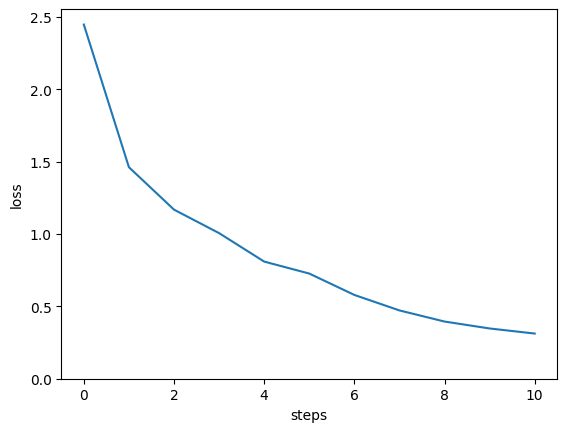

In [58]:
training_tcn(tcn_model=tcn_model,n_epochs=84,loader=loader, loss_fn = loss_fn, training=True)

              precision    recall  f1-score   support

           0       0.45      0.11      0.18    307200
           1       0.73      0.94      0.82    189220
           2       0.25      0.23      0.24    341910
           3       0.31      0.24      0.27    354220
           4       0.01      0.01      0.01    265570
           5       0.27      0.46      0.34    399680

    accuracy                           0.30   1857800
   macro avg       0.34      0.33      0.31   1857800
weighted avg       0.31      0.30      0.28   1857800



(0.31090037039960905,
 np.float64(1.8277172618601696),
 np.float64(0.3039425559380378))

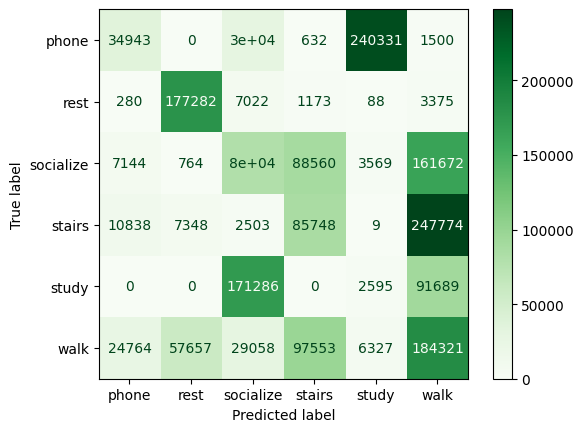

In [59]:
eval_function(tcn_model,test_loader,loss_fn, test_mode=True)

### HP Tuning (Do not run before training due to unknown bug)

In [37]:
def objective_fn(trial):
    """objective function for hp tuning"""
    #hp space
    num_channels = trial.suggest_categorical("num_channels", [
    [16, 32, 64],
    [32, 64, 128],
    [64, 64, 64],
    [128, 64, 32],
    [16, 16, 32, 32],
    [8, 16, 32, 64, 128],
    [32, 64],
    [64, 128],
    [64, 128, 256],
    [16, 32, 64, 64],
    [16, 32, 64, 32],
    [32, 64, 64, 32],
])

    kernel_size = trial.suggest_int("kernel_size", 2, 7)
    dilation_reset = trial.suggest_categorical("dilation_reset", [8, 16, 32])
    use_norm = trial.suggest_categorical("use_norm", ["weight_norm", "batch_norm", None])
    activation = trial.suggest_categorical("activation", ["relu", "tanh", "leaky_relu"])
    kernel_initializer = trial.suggest_categorical("kernel_initializer", ["xavier_uniform", "kaiming_uniform"])
    use_gate = trial.suggest_categorical("use_gate", [True, False])
    use_skip_connections = trial.suggest_categorical("use_skip_connections", [True, False])
    causal = trial.suggest_categorical("causal", [True, False])
    dropout = trial.suggest_float("dropout", 0.0, 0.3)
    n_epochs = trial.suggest_int("num_epochs",10,200)




    if activation == "tanh" and kernel_initializer == "kaiming_uniform":
        raise optuna.TrialPruned()  #prune invalid trial

    tcn_model = TCN(num_inputs=X.shape[2], num_channels = num_channels, kernel_size = kernel_size,
                dilation_reset = dilation_reset, causal =causal, use_norm = use_norm,
                activation =activation,kernel_initializer = kernel_initializer,
                use_skip_connections =use_skip_connections,embedding_shapes =None,use_gate =use_gate,
                 lookahead = 0, output_projection  =6, output_activation = None, dropout = dropout ).to(device)

    #loss fn etc
    optimizer = torch.optim.Adam(tcn_model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()
    #training
    training_tcn(tcn_model,n_epochs=10)
    f1 = eval_function(tcn_model,val_loader,loss_fn, test_mode=False)
    return f1


In [38]:
study = optuna.create_study(direction="maximize")
study.optimize(objective_fn, n_trials=50, show_progress_bar=True, gc_after_trial=True)
best_params = study.best_params
print("Best hyperparameters:", best_params)

[I 2025-06-20 11:46:01,308] A new study created in memory with name: no-name-65ae3c4a-ab32-412e-a2b7-5db52cc83408


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [16, 32, 64] which is of type list.
  warnings.warn(message)
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [32, 64, 128] which is of type list.
  warnings.warn(message)
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [64, 64, 64] which is of type list.
  warnings.warn(message)
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent s

[I 2025-06-20 11:46:49,185] Trial 0 finished with value: 0.08861027257061531 and parameters: {'num_channels': [16, 32, 64], 'kernel_size': 5, 'dilation_reset': 16, 'use_norm': 'batch_norm', 'activation': 'relu', 'kernel_initializer': 'xavier_uniform', 'use_gate': True, 'use_skip_connections': True, 'causal': True, 'dropout': 0.2557640266288176, 'num_epochs': 100}. Best is trial 0 with value: 0.08861027257061531.


/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [16, 32, 64] which is of type list.
  warnings.warn(message)
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [32, 64, 128] which is of type list.
  warnings.warn(message)
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [64, 64, 64] which is of type list.
  warnings.warn(message)
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent s

...

[I 2025-06-20 12:27:26,022] Trial 46 finished with value: 0.18601550697707103 and parameters: {'num_channels': [32, 64], 'kernel_size': 6, 'dilation_reset': 8, 'use_norm': None, 'activation': 'leaky_relu', 'kernel_initializer': 'kaiming_uniform', 'use_gate': False, 'use_skip_connections': False, 'causal': True, 'dropout': 0.1274598000904525, 'num_epochs': 96}. Best is trial 2 with value: 0.4435934953113709.


/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [16, 32, 64] which is of type list.
  warnings.warn(message)
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [32, 64, 128] which is of type list.
  warnings.warn(message)
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [64, 64, 64] which is of type list.
  warnings.warn(message)
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent s

[I 2025-06-20 12:28:16,197] Trial 47 finished with value: 0.1553298463101564 and parameters: {'num_channels': [16, 32, 64, 64], 'kernel_size': 4, 'dilation_reset': 32, 'use_norm': None, 'activation': 'leaky_relu', 'kernel_initializer': 'kaiming_uniform', 'use_gate': False, 'use_skip_connections': False, 'causal': True, 'dropout': 0.06534264143246478, 'num_epochs': 90}. Best is trial 2 with value: 0.4435934953113709.


/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [16, 32, 64] which is of type list.
  warnings.warn(message)
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [32, 64, 128] which is of type list.
  warnings.warn(message)
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [64, 64, 64] which is of type list.
  warnings.warn(message)
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent s

[I 2025-06-20 12:28:16,413] Trial 48 pruned. 
[I 2025-06-20 12:29:21,444] Trial 49 finished with value: 0.3669942799426828 and parameters: {'num_channels': [8, 16, 32, 64, 128], 'kernel_size': 6, 'dilation_reset': 8, 'use_norm': None, 'activation': 'leaky_relu', 'kernel_initializer': 'kaiming_uniform', 'use_gate': False, 'use_skip_connections': False, 'causal': True, 'dropout': 0.09650712432247524, 'num_epochs': 122}. Best is trial 2 with value: 0.4435934953113709.
Best hyperparameters: {'num_channels': [32, 64, 64, 32], 'kernel_size': 5, 'dilation_reset': 8, 'use_norm': 'weight_norm', 'activation': 'leaky_relu', 'kernel_initializer': 'kaiming_uniform', 'use_gate': False, 'use_skip_connections': False, 'causal': False, 'dropout': 0.1424437526687838, 'num_epochs': 84}
